<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB42 · MJCF: tu propio robot

**Parte 5 · La física del cuerpo — Lección 7**

> En esta parte has escrito varios "planos" de MuJoCo a mano: un péndulo (NB37), un bloque que vuelca (NB38), un péndulo con una IMU (NB41). Te dije cada vez "léelo como una lista de piezas, ya lo veremos a fondo".

Hoy es "a fondo". Vas a aprender el lenguaje en el que se describen los robots de MuJoCo, el **MJCF**, y con él vas a construir, pieza a pieza, **tu propio robot bípedo**. Lo llamaremos **Zancudo**. Tendrá un torso, dos piernas con cadera, rodilla y tobillo, motores con un PD dentro (NB40) y una IMU (NB41). Al final lo guardaremos en un fichero y comprobaremos que se sostiene de pie... y cuánto empujón aguanta.

Esto es una habilidad de profesional de verdad. Hasta ahora usabas robots hechos por otros (Hopper, Walker2d, el humanoide). Un ingeniero de robótica tiene que poder **describir** el robot de su empresa en el simulador, **modificarlo** (¿y si el pie fuera más largo? ¿y si el torso pesara más?) y **comprobar** que la descripción es correcta. En el NB43 intentaremos hacer andar a Zancudo.


## 1 · XML: etiquetas dentro de etiquetas

MJCF está escrito en **XML**, un formato de texto muy usado para describir cosas con estructura. Solo tiene tres ideas.

**1. Etiquetas.** Una cosa se describe con una **etiqueta de apertura** y una **de cierre**, con el mismo nombre entre `< >`; la de cierre lleva una barra `/`:

```xml
<body> ... aquí va lo de dentro ... </body>
```

Si una etiqueta no tiene nada dentro, se puede abrir y cerrar a la vez, con la barra al final: `<geom ... />`.

**2. Atributos.** Dentro de la etiqueta de apertura se ponen **datos** de la cosa, como `nombre="valor"`, siempre con comillas:

```xml
<geom type="box" size="0.1 0.1 0.1" mass="2"/>
```

Se lee: "una geometría de tipo caja, de tamaño 0,1 × 0,1 × 0,1, con 2 kg de masa". Los números van separados por **espacios** (no por comas) y con **punto** decimal.

**3. Anidar.** Las etiquetas pueden ir **dentro** de otras. Y eso forma un **árbol**, como un árbol genealógico: la de fuera es la "madre" y las de dentro sus "hijas":

```xml
<body name="muslo">              ← madre
  <joint .../>                   ← hija: la articulación del muslo
  <geom .../>                    ← hija: la forma del muslo
  <body name="pierna">           ← hija... que es madre de las suyas
    <joint .../>
    <geom .../>
  </body>
</body>
```

En un robot, ese árbol es **exactamente** el cuerpo: la pierna está **dentro** del muslo porque **cuelga** de él. Si mueves el muslo, la pierna va detrás (¡la cadena del NB36!).

Los espacios del principio de cada línea (la sangría) **no** son obligatorios en XML, al revés que en Python (NB07); solo sirven para que lo lean los humanos. Pero úsalos siempre: un XML sin sangría es ilegible.


## 2 · El esqueleto de un fichero MJCF

Todo MJCF va dentro de una gran etiqueta `<mujoco>`, y tiene varias **secciones**. Las que vamos a usar:

| Sección | Qué describe |
|---|---|
| `<compiler>` | Ajustes generales; por ejemplo, si los ángulos van en grados o radianes. |
| `<option>` | Ajustes de la física: el pasito (`timestep`), la gravedad... |
| `<visual>`, `<asset>` | El aspecto: luces, colores, texturas (el suelo a cuadros). |
| `<default>` | Valores por defecto, para no repetirlos en cada pieza. |
| `<worldbody>` | **El mundo y el robot**: el árbol de piezas. La sección principal. |
| `<actuator>` | Los **motores**. |
| `<sensor>` | Los **sensores**. |

Y dentro de `<worldbody>`, tres etiquetas que son el 90 % del trabajo:

- **`<body>`**: una **pieza** (un cuerpo rígido, NB01). Tiene posición y orientación, y es "madre" de lo que va dentro.
- **`<geom>`**: la **forma** de una pieza (caja, esfera, cápsula...). Sirve para dibujarla, para los **choques** y para calcular su **masa**. Una pieza puede tener varias.
- **`<joint>`**: la **articulación** que une una pieza con su madre. Sin ella, la pieza va **soldada** a su madre.

Vamos a construir, poco a poco. Como en los notebooks anteriores, escribiremos el MJCF como un **texto de Python** (con las tres comillas, NB20) y se lo daremos a MuJoCo con `from_xml_string`.


## 3 · Paso 1: un mundo con suelo y una caja

Lo mínimo: un suelo y una caja que cae. Primero las herramientas, y una función para hacer una foto con la cámara de MuJoCo (como en el NB38):

In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"
import numpy as np
import matplotlib.pyplot as plt
import mujoco

def foto(modelo, datos, camara=-1, ancho=400, alto=300):
    with mujoco.Renderer(modelo, height=alto, width=ancho) as renderer:
        renderer.update_scene(datos, camera=camara)
        imagen = renderer.render()
    plt.figure(figsize=(ancho / 100, alto / 100))
    plt.imshow(imagen)
    plt.axis("off")
    plt.show()

(`camera=-1` es la cámara "libre" por defecto, que mira al centro de la escena.) Ahora, el primer mundo:

In [2]:
mundo = '''
<mujoco>
  <worldbody>
    <light pos="0 0 3" dir="0 0 -1"/>
    <geom type="plane" size="2 2 0.1" rgba="0.8 0.85 0.8 1"/>
    <body pos="0 0 1">
      <freejoint/>
      <geom type="box" size="0.1 0.1 0.1" rgba="0.9 0.5 0.2 1"/>
    </body>
  </worldbody>
</mujoco>
'''

Línea a línea:

- `<light>`: una **luz** a 3 m de altura, apuntando hacia abajo (`dir`, la dirección). Sin luz, todo sale negro.
- El primer `<geom>`, directamente en el mundo: un **plano** (`type="plane"`), el suelo, de 2 × 2 m (el tercer número del `size` es para el dibujo de la cuadrícula). `rgba` es su color: **r**ojo, **v**erde (*green*), **a**zul (*blue*) y **a**lfa (opacidad), de 0 a 1 (NB12: un color es un vector de 4 números).
- `<body pos="0 0 1">`: una **pieza** a 1 m de altura (x, y, z).
- `<freejoint/>`: la articulación **libre** del NB38: la pieza puede moverse y girar en cualquier dirección, como un objeto suelto.
- Su `<geom>`: una caja naranja. En una caja, `size` son las **mitades** de sus medidas: esta mide 20 cm por lado.

¿Y la masa? No la hemos puesto. MuJoCo la calcula sola, a partir del **volumen** de la forma y de una **densidad** por defecto de 1.000 kg/m³ (la del agua):


In [3]:
modelo = mujoco.MjModel.from_xml_string(mundo)
datos = mujoco.MjData(modelo)
print("masa de la caja:", modelo.body_mass[1], "kg")

masa de la caja: 8.000000000000002 kg


**8 kg**: 0,2 × 0,2 × 0,2 m = 0,008 m³ de "agua". Dejémosla caer un segundo y hagamos una foto:

altura de la caja: 0.1 m


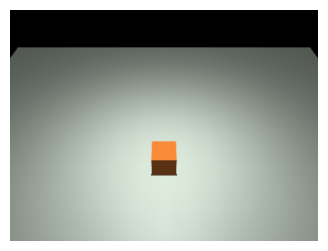

In [4]:
for i in range(500):                  # el pasito por defecto es 0,002 s: 500 pasitos = 1 segundo
    mujoco.mj_step(modelo, datos)
print("altura de la caja:", datos.qpos[2].round(3), "m")
foto(modelo, datos)

La caja ha caído y descansa en el suelo, con su centro a **0,1 m** (media caja) de altura. (Con una `freejoint`, `qpos` tiene 7 números: 3 de posición y 4 de orientación; el tercero es la altura.)


## 4 · Paso 2: las posiciones son relativas a la madre

Ahora la idea más importante de MJCF, y la que más errores causa: **la `pos` de un `<body>` se mide desde su madre, no desde el mundo**.

Pruébalo con la mano: tu codo está "a unos 30 cm de tu hombro, hacia abajo", estés donde estés. Si te mueves, el codo se mueve contigo, pero sigue a 30 cm del hombro. Describir el cuerpo así, cada pieza **respecto de su madre**, es lo que permite que el árbol funcione: al mover una pieza, todo lo que cuelga de ella se mueve con ella.

```xml
<body name="torso" pos="0 0 1">          ← a 1 m del suelo (su madre es el mundo)
  <body name="muslo" pos="0 0 -0.2">     ← 0,2 m por DEBAJO del torso: a 0,8 m del suelo
    <body name="pierna" pos="0 0 -0.4">  ← 0,4 m por debajo del muslo: a 0,4 m del suelo
```

Igual con las `<geom>`: sus posiciones van respecto de la pieza a la que pertenecen. Para las formas alargadas, hay un atajo muy cómodo: **`fromto`** ("desde-hasta"), con 6 números: el punto de inicio (x, y, z) y el de final. Ya lo usaste en el NB37: `fromto="0 0 0  0 0 -0.4"` es un palo que va desde el origen de su pieza hasta 0,4 m por debajo. Y las **articulaciones** se colocan, por defecto, en el **origen** de su pieza: por eso conviene poner el origen de cada pieza justo en su articulación (el muslo, en la cadera; la pierna, en la rodilla).

### Las formas

Las formas más usadas, y qué significa su `size` en cada una:

| `type` | Forma | `size` |
|---|---|---|
| `plane` | Suelo infinito | medio ancho, medio largo, (cuadrícula) |
| `box` | Caja | las **mitades** de ancho, fondo y alto |
| `sphere` | Esfera | el radio |
| `capsule` | Cápsula: cilindro con media esfera en cada punta | el radio (y el largo, con `fromto`) |
| `cylinder` | Cilindro | el radio (y el largo, con `fromto`) |

Los robots de investigación usan casi siempre **cápsulas**: sus puntas redondeadas hacen que los choques sean suaves y fáciles de calcular (fíjate en las piernas de Hopper y Walker2d). Nosotros también.


## 5 · Paso 3: las articulaciones

Una pieza sin `<joint>` va **soldada** a su madre. Los tipos de articulación:

| `type` | Qué permite | En el cuerpo (NB01) |
|---|---|---|
| `hinge` | **Bisagra**: girar alrededor de un eje | Rodilla, codo |
| `slide` | **Deslizar** a lo largo de un eje | (los raíles, el carrito del péndulo del NB34) |
| `ball` | **Rótula**: girar en todas direcciones | Hombro, cadera de un humano |
| `free` | Totalmente **libre** (`<freejoint/>`) | Un objeto suelto |

Y sus atributos más importantes:

- **`axis`**: el **eje** de giro (o de deslizamiento), como un vector (NB12). `"0 1 0"` es el eje y (de lado): una bisagra con ese eje hace que la pieza gire **en el plano** delante-arriba, como las de Hopper. El **sentido** del eje decide hacia dónde es "positivo": con `"0 -1 0"`, un ángulo positivo lleva la pieza **hacia delante** (es el convenio de Hopper que usamos en el NB36).
- **`range`**: los **límites** del ángulo, como una rodilla que no se dobla hacia delante. (Y `<compiler angle="radian"/>` dice que los ángulos van en radianes, NB36. Por defecto MuJoCo los espera en **grados**: ¡otra trampa de unidades!)
- **`damping`**: un poco de **amortiguación** (NB38) en la articulación, como el rozamiento de un engranaje.
- **`armature`**: la **inercia reflejada** del motor y su reductora (NB40), que MuJoCo suma a la de la articulación.

### La raíz de un robot plano

El torso de nuestro robot tiene que poder moverse **libre** por el mundo (andar, caerse...). En 3D usaríamos una `freejoint`. Pero Zancudo va a ser un robot **plano**, como Hopper y Walker2d (NB35): vive en un dibujo de perfil y no se puede caer de lado. Así que, en vez de una articulación libre, el torso lleva **tres**:

- un `slide` en el eje x: avanzar o retroceder;
- un `slide` en el eje z: subir o bajar;
- un `hinge` en el eje y: inclinarse hacia delante o hacia atrás.

Tres libertades, las justas para moverse en un plano. Es exactamente lo que hacen Hopper (`rootx`, `rootz`, `rooty`, NB35) y Walker2d.


## 6 · Paso 4: una pierna, fabricada por Python

Una pierna de Zancudo tiene tres piezas: **muslo** (40 cm), **pierna** (40 cm) y **pie** (20 cm), con tres bisagras: **cadera**, **rodilla** y **tobillo**. Y Zancudo tiene **dos** piernas iguales, que solo se diferencian en el nombre, el color y en que una está un poco a la derecha y la otra a la izquierda.

Escribir dos veces lo mismo es mala idea (NB10: si te equivocas, te equivocas dos veces). Así que fabricaremos el texto de una pierna con una **función de Python** que reciba lo que cambia, y con un **f-string** (NB20) que meta esos valores dentro del XML:


In [5]:
def pierna(lado, y, color):
    return f'''
      <body name="muslo_{lado}" pos="0 {y} 0">
        <joint name="cadera_{lado}" range="-1.57 1.57"/>
        <geom type="capsule" fromto="0 0 0  0 0 -0.4" size="0.05" mass="3" rgba="{color}"/>
        <body name="pierna_{lado}" pos="0 0 -0.4">
          <joint name="rodilla_{lado}" range="-2.6 0"/>
          <geom type="capsule" fromto="0 0 0  0 0 -0.4" size="0.04" mass="2" rgba="{color}"/>
          <body name="pie_{lado}" pos="0 0 -0.4">
            <joint name="tobillo_{lado}" range="-0.78 0.78"/>
            <geom name="pie_{lado}" type="capsule" fromto="-0.06 0 -0.03  0.14 0 -0.03" size="0.03" mass="0.8" rgba="{color}"/>
          </body>
        </body>
      </body>'''

Léela como un árbol: el **muslo** (con su origen en la cadera) contiene la **pierna** (con su origen en la rodilla, 0,4 m más abajo), que contiene el **pie** (con su origen en el tobillo, otros 0,4 m más abajo). Cada pieza, con su bisagra y su cápsula.

Detalles:

- Los **límites** en radianes: la cadera, ±1,57 (±90°); la rodilla, de −2,6 a 0 (solo se dobla hacia atrás, como la tuya y la de Hopper); el tobillo, ±0,78 (±45°).
- Las **masas** las ponemos a mano (`mass`), en vez de dejar que MuJoCo las calcule con la densidad del agua: muslo 3 kg, pierna 2 kg, pie 0,8 kg.
- El **pie** es una cápsula tumbada, de 6 cm por detrás del tobillo a 14 cm por delante, 3 cm por debajo de él. Como el de Hopper, sobresale más hacia delante.
- La **y** coloca la pierna a un lado del torso. En un robot plano no hace falta para la física, pero si las dos piernas estuvieran en el mismo sitio se atravesarían en el dibujo.

¿Y el eje de las bisagras? No lo hemos puesto en cada `<joint>`: lo pondremos **una sola vez** como valor por defecto (sección 8). Comprobemos que la función hace lo que queremos, mirando el principio del texto de la pierna derecha:


In [6]:
print(pierna("d", -0.1, "0.85 0.55 0.25 1")[:200])


      <body name="muslo_d" pos="0 -0.1 0">
        <joint name="cadera_d" range="-1.57 1.57"/>
        <geom type="capsule" fromto="0 0 0  0 0 -0.4" size="0.05" mass="3" rgba="0.85 0.55 0.25 1"/>
   


El `{lado}` se ha convertido en `d` (derecha) y la `{y}` en −0.1. Python escribe el XML por nosotros.


## 7 · Paso 5: los motores

En la sección `<actuator>` se ponen los motores. MuJoCo tiene varios tipos; los dos que más se usan en robots con patas:

**`<motor>`**: un motor de **par**. La acción (`ctrl`) se multiplica por el `gear` y sale un par. Es el que usan Hopper, Walker2d y el humanoide (NB35, NB37): la política decide el par directamente.

```xml
<motor joint="rodilla_d" gear="150" ctrlrange="-1 1"/>
```

**`<position>`**: un motor de **posición**. La acción es el **ángulo objetivo**, y el motor lo persigue con... ¡un **PD** por dentro (NB40)! Sus atributos son las ganancias: `kp` (el muelle) y `kv` (el amortiguador; *v* de velocidad, nuestro Kd). Con `forcerange` limitamos el par máximo que puede dar (la **saturación** del NB40), porque un PD sin límite podría pedir pares imposibles:

```xml
<position joint="rodilla_d" kp="300" kv="20" forcelimited="true" forcerange="-150 150" ctrlrange="-2.6 0"/>
```

Zancudo llevará motores de **posición**, como los robots reales (NB40: la política da ángulos objetivo, el PD los persigue). Así, con la acción a cero, el robot pedirá "todas las articulaciones a 0": **de pie y recto**. Un motor por articulación, con el `ctrlrange` igual a los límites de la articulación:


In [7]:
def motores(lado):
    return f'''
    <position name="m_cadera_{lado}" joint="cadera_{lado}" ctrlrange="-1.57 1.57"/>
    <position name="m_rodilla_{lado}" joint="rodilla_{lado}" ctrlrange="-2.6 0"/>
    <position name="m_tobillo_{lado}" joint="tobillo_{lado}" ctrlrange="-0.78 0.78"/>'''

(Las ganancias y el límite de par no están aquí: van en los valores por defecto, para todos los motores a la vez. Ahora lo vemos.)


## 8 · Paso 6: los valores por defecto y el robot completo

Muchas cosas se repiten en todas las articulaciones (el eje, la amortiguación...), en todas las formas (el rozamiento...) y en todos los motores (kp, kv, el límite de par). En vez de escribirlas en cada una, se ponen **una vez** en `<default>`, y todas las de ese tipo las toman salvo que digan otra cosa:

```xml
<default>
  <joint type="hinge" axis="0 -1 0" damping="1" armature="0.01"/>
  <geom friction="1 0.005 0.0001" rgba="..."/>
  <position kp="300" kv="20" forcelimited="true" forcerange="-150 150"/>
</default>
```

(`friction` tiene tres números: el rozamiento al **deslizar**, que es el importante, y dos muy pequeños para el rozamiento al **girar** y al **rodar**.)

Ya podemos montar a **Zancudo** entero. Una función que junta todas las piezas. Fíjate en que las tres articulaciones de la raíz plana (sección 5) cambian el `type` y el `axis` de los valores por defecto, y no llevan amortiguación (`damping="0"`) ni inercia de motor (`armature="0"`), porque no son articulaciones de verdad, sino la libertad del torso para moverse por el mundo:


In [8]:
NARANJA = "0.85 0.55 0.25 1"
MORADO = "0.6 0.4 0.7 1"

def zancudo():
    return f'''
<mujoco model="zancudo">
  <compiler angle="radian"/>
  <option timestep="0.002"/>
  <default>
    <joint type="hinge" axis="0 -1 0" damping="1" armature="0.01"/>
    <geom friction="1 0.005 0.0001" rgba="{NARANJA}"/>
    <position kp="300" kv="20" forcelimited="true" forcerange="-150 150"/>
  </default>
  <visual>
    <headlight ambient="0.4 0.4 0.4" diffuse="0.6 0.6 0.6"/>
  </visual>
  <asset>
    <texture type="skybox" builtin="gradient" rgb1="0.5 0.6 0.7" rgb2="0.1 0.1 0.15" width="200" height="200"/>
    <texture name="cuadros" type="2d" builtin="checker" rgb1="0.75 0.8 0.75" rgb2="0.45 0.5 0.45" width="300" height="300"/>
    <material name="suelo" texture="cuadros" texrepeat="10 10"/>
  </asset>
  <worldbody>
    <light pos="0 0 3" dir="0 0 -1" directional="true"/>
    <geom name="suelo" type="plane" size="20 20 0.1" material="suelo" rgba="1 1 1 1"/>
    <body name="torso" pos="0 0 0.865">
      <camera name="lado" mode="trackcom" pos="0 -3 0" xyaxes="1 0 0  0 0 1"/>
      <joint name="raiz_x" type="slide" axis="1 0 0" damping="0" armature="0"/>
      <joint name="raiz_z" type="slide" axis="0 0 1" damping="0" armature="0"/>
      <joint name="raiz_giro" type="hinge" axis="0 1 0" damping="0" armature="0"/>
      <geom name="torso" type="capsule" fromto="0 0 0.05  0 0 0.45" size="0.08" mass="12"/>
      <site name="imu" pos="0 0 0.3"/>
      {pierna("d", -0.1, NARANJA)}
      {pierna("i", 0.1, MORADO)}
    </body>
  </worldbody>
  <actuator>
    {motores("d")}
    {motores("i")}
  </actuator>
  <sensor>
    <accelerometer name="acelerometro" site="imu"/>
    <gyro name="giroscopo" site="imu"/>
  </sensor>
</mujoco>
'''

Repasemos las partes nuevas:

- **`<visual>` y `<asset>`**: el aspecto. Una luz suave que va con la cámara (`headlight`), un cielo degradado (`skybox`) y un suelo a cuadros (una **textura** de cuadros, usada por un **material**). No afectan a la física.
- **El torso**: su origen está en la **cadera**, a 0,865 m del suelo (0,4 + 0,4 de las piernas, más los 3 cm del pie y los 3 cm de su radio, más medio centímetro de margen para que empiece justo encima del suelo). La cápsula del torso va **hacia arriba** desde ahí: de 0,05 a 0,45 m, con 12 kg.
- **La cámara** `lado`, dentro del torso: a 3 m a su lado, mirándolo de perfil, y con `mode="trackcom"` sigue a su centro de masas (como la cámara `track` de Hopper).
- **El `site` `imu`**: un punto marcado en el torso, donde pegamos el acelerómetro y el giróscopo (NB41).
- **Las dos piernas** y **los seis motores**, fabricados por nuestras funciones. Las `{ }` del f-string meten ahí sus textos.

Fíjate en el **orden** de las articulaciones dentro de `qpos`: primero las tres de la raíz (x, z, giro), después cadera, rodilla y tobillo de la derecha, y después las de la izquierda. Es el orden en el que aparecen en el texto.


## 9 · Paso 7: cuando MuJoCo se queja

Antes de cargar a Zancudo, una habilidad imprescindible: **leer los errores** de MuJoCo. Al escribir XML a mano es facilísimo equivocarse. Por ejemplo, olvidar una comilla, o escribir mal el nombre de una articulación en un motor. Probemos lo segundo, a propósito: un motor que mueve una articulación llamada `rodila_d` (con una sola ele):


In [9]:
plano_con_error = zancudo().replace('joint="rodilla_d"', 'joint="rodila_d"')
mujoco.MjModel.from_xml_string(plano_con_error)

ValueError: Error: unknown transmission target 'rodila_d' for actuator id = 1
Element name 'm_rodilla_d', id 1, line 59

MuJoCo se niega a construir el modelo y lo dice con un `ValueError` (los errores de Python del NB22). Lee el mensaje de la última línea: dice **qué** ha fallado (*unknown transmission target 'rodila_d'*: "destino de transmisión desconocido"; la **transmisión** es lo que une un motor con su articulación, y no hay ninguna articulación llamada así) y **dónde** (en el motor `m_rodilla_d`, y en qué línea del texto). Con esa información, el error se arregla en segundos. La regla de siempre: **lee el mensaje entero antes de tocar nada**.


## 10 · Guardar a Zancudo en un fichero

Escribir el robot desde Python es cómodo para construirlo, pero lo normal es guardarlo en un **fichero** `.xml`, para poder usarlo desde cualquier programa (como los `.xml` de Hopper y Walker2d que trae Gymnasium). Lo guardamos en una carpeta `robots/`, con lo aprendido en el NB26 (`pathlib`):


In [10]:
from pathlib import Path

carpeta = Path("robots")
carpeta.mkdir(exist_ok=True)
fichero = carpeta / "zancudo.xml"
fichero.write_text(zancudo())
print("guardado en", fichero, "-", len(fichero.read_text().splitlines()), "líneas")

guardado en robots/zancudo.xml - 70 líneas


Y lo cargamos **desde el fichero**, con `from_xml_path` (en vez de `from_xml_string`). Así lo cargaremos en el NB43:

In [11]:
modelo = mujoco.MjModel.from_xml_path(str(fichero))
datos = mujoco.MjData(modelo)
print("piezas:", modelo.nbody, "| articulaciones:", modelo.njnt, "| números en qpos:", modelo.nq, "| motores:", modelo.nu, "| sensores:", modelo.nsensor)

piezas: 8 | articulaciones: 9 | números en qpos: 9 | motores: 6 | sensores: 2


- **8 piezas**: el mundo, el torso, y 3 por pierna (muslo, pierna, pie).
- **9 articulaciones**: 3 de la raíz + 3 por pierna. Y 9 números en `qpos` (cada una de estas articulaciones tiene un número).
- **6 motores** y **2 sensores** (el acelerómetro y el giróscopo).


## 11 · Pruebas: ¿está bien hecho?

Un ingeniero nunca se fía de un robot recién descrito: lo **comprueba**. Primera prueba: las **masas** y el **centro de masas** (NB38). ¿Pesa lo que esperamos?


In [12]:
for i in range(1, modelo.nbody):
    print(f"{mujoco.mj_id2name(modelo, mujoco.mjtObj.mjOBJ_BODY, i):>9}: {modelo.body_mass[i]:4.1f} kg")
print(f"    total: {modelo.body_mass.sum():.1f} kg")

mujoco.mj_forward(modelo, datos)
print("centro de masas (x, y, altura):", datos.subtree_com[1].round(3))

    torso: 12.0 kg
  muslo_d:  3.0 kg
 pierna_d:  2.0 kg
    pie_d:  0.8 kg
  muslo_i:  3.0 kg
 pierna_i:  2.0 kg
    pie_i:  0.8 kg
    total: 23.6 kg
centro de masas (x, y, altura): [0.003 0.    0.783]


**23,6 kg** (12 del torso + 2 × 5,8 de cada pierna), con el centro de masas a **0,78 m** de altura, casi justo encima de los tobillos (x ≈ 0,003). Todo como esperábamos. Ahora, una foto en su postura inicial:

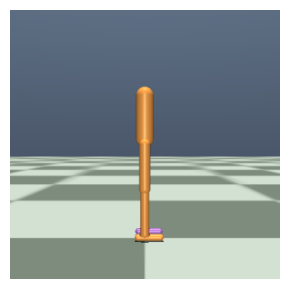

In [13]:
foto(modelo, datos, camara="lado", ancho=350, alto=350)

Ahí está **Zancudo**, de perfil: el torso naranja y las dos piernas (la morada, la izquierda, queda detrás). Segunda prueba: ¿se **sostiene**? Todas las acciones a 0 (los motores de posición piden "todas las articulaciones a 0": recto), y lo dejamos 3 segundos:

In [14]:
mujoco.mj_resetData(modelo, datos)
datos.ctrl[:] = 0
for i in range(1500):
    mujoco.mj_step(modelo, datos)
print(f"tras 3 s: el torso ha bajado {-datos.qpos[1] * 100:.1f} cm, inclinado {datos.qpos[2]:+.3f} rad, se ha movido {datos.qpos[0] * 100:+.1f} cm")

tras 3 s: el torso ha bajado 0.6 cm, inclinado -0.002 rad, se ha movido -0.2 cm


(`mj_resetData` devuelve el robot a su postura inicial, la del plano.) El torso apenas ha bajado medio centímetro (lo que tardan los pies en asentarse en el suelo blando de MuJoCo, NB38) y sigue recto. **Zancudo se sostiene de pie** con sus propios motores, gracias a los PD de sus `position`.


### La prueba del empujón

Tercera prueba: ¿cuánto **empujón** aguanta? MuJoCo permite aplicar una **fuerza externa** a cualquier pieza con `datos.xfrc_applied` (de *external force*): una fila por pieza, con 6 números (3 de fuerza y 3 de par). Empujaremos el torso **hacia delante** (eje x) durante **0,05 s** (25 pasitos), después de un segundo de pie, y miraremos si al final sigue de pie:


In [15]:
torso = mujoco.mj_name2id(modelo, mujoco.mjtObj.mjOBJ_BODY, "torso")

def empujar(fuerza, postura=np.zeros(6), segundos=3):
    mujoco.mj_resetData(modelo, datos)
    datos.ctrl[:] = postura
    lo_mas_bajo = 0.0
    for i in range(round(segundos / 0.002)):
        if 500 <= i < 525:                           # del segundo 1 al 1,05
            datos.xfrc_applied[torso, 0] = fuerza    # empujón hacia delante
        else:
            datos.xfrc_applied[torso, 0] = 0
        mujoco.mj_step(modelo, datos)
        lo_mas_bajo = min(lo_mas_bajo, datos.qpos[1])
    return lo_mas_bajo < -0.3                        # ¿ha llegado a bajar el torso más de 30 cm? Entonces se ha caído

In [16]:
for fuerza in [100, 180, 200]:
    print(f"empujón de {fuerza} N:", "SE CAE" if empujar(fuerza) else "aguanta")

empujón de 100 N: aguanta
empujón de 180 N: aguanta
empujón de 200 N: SE CAE


(La función devuelve `True` si el torso llega a bajar más de 30 cm en algún momento: eso solo pasa si el robot se ha caído. Mirar solo la postura final engaña, porque después de un empujón el robot se **balancea** un rato.)

Con **100 N** y con **180 N** durante 0,05 s, Zancudo se tambalea y aguanta. Con **200 N**, se cae de bruces.

¿Por qué justo ahí? Con lo aprendido en esta parte podemos explicarlo. Un empujón de 200 N durante 0,05 s le da al robot de 23,6 kg una velocidad de unos 200 × 0,05 / 23,6 ≈ **0,42 m/s** (la segunda ley de Newton, NB37). Su centro de masas está a 0,78 m de altura, así que su ω es √(9,81 / 0,78) ≈ 3,5 y su **punto de captura** (NB39) queda a 0,42 / 3,5 ≈ **12 cm** por delante. Con 180 N, a unos **11 cm**. La punta de sus pies llega a 14 cm del tobillo, pero ya sabemos (NB38) que el borde **útil** de la base es algo más corto que el geométrico. Y además Zancudo no usa el tobillo con cabeza: su PD solo intenta mantener el ángulo del tobillo en 0, no llevar el centro de presión justo al punto de captura (NB39). El resultado: el límite real queda entre 11 y 12 cm. Y como Zancudo **no sabe dar pasos** (sus motores solo mantienen la postura), cuando el punto de captura sale de lo que su pie puede aguantar, se cae.

Para aguantar empujones más fuertes, Zancudo tendría que **dar un paso**. Y eso ya no lo hace un PD: lo tiene que decidir una **política**. Eso es el NB43.


## 12 · El visor interactivo

Una última herramienta. Si ejecutas esto en un ordenador **con pantalla** (por ejemplo, la Raspberry Pi con su monitor), MuJoCo trae un **visor** en el que puedes ver el robot en 3D, girar la cámara con el ratón, pausar, avanzar paso a paso, mover los motores con barras deslizantes y hasta **empujar** las piezas con el ratón (doble clic en una pieza, y Ctrl + arrastrar). Desde una terminal (NB26), en la carpeta `notebooks`:

```bash
python -m mujoco.viewer --mjcf=robots/zancudo.xml
```

Es la mejor forma de comprobar un robot nuevo: en dos minutos de jugar con él descubres errores que en el código no se ven (una pieza al revés, una articulación que gira hacia el lado equivocado...). No lo ejecutamos aquí porque el notebook no tiene pantalla.


## 13 · Resumen de la lección

1. **XML**: etiquetas `<x> ... </x>` (o `<x/>`), **atributos** `nombre="valor"` y **anidar** = árbol. En MJCF, el árbol de `<body>` es el cuerpo del robot.
2. Secciones de MJCF: `compiler`, `option`, `visual`/`asset`, `default`, **`worldbody`**, **`actuator`**, **`sensor`**.
3. `<body>` = pieza; `<geom>` = forma (choques, dibujo y masa); `<joint>` = articulación con la madre (sin ella, soldada).
4. **Las posiciones son relativas a la madre.** `fromto` para formas alargadas. Poner el origen de cada pieza en su articulación.
5. Formas: `plane`, `box` (size = mitades), `sphere`, `capsule`, `cylinder`. Masa con `mass`, o con la densidad (por defecto, la del agua).
6. Articulaciones: `hinge`, `slide`, `ball`, `free`; `axis` (su sentido decide el signo), `range` (¡radianes o grados según `compiler`!), `damping`, `armature`. Robot plano: raíz de 3 (slide x, slide z, hinge y).
7. Motores: `<motor>` (par = ctrl × gear) y `<position>` (ángulo objetivo con un PD dentro: `kp`, `kv`; límite con `forcerange`).
8. `<default>` evita repetir; las **funciones de Python con f-strings** fabrican piezas repetidas.
9. Leer los errores de MuJoCo (`ValueError`: qué y dónde). Guardar en `.xml` y cargar con `from_xml_path`.
10. **Zancudo**: 8 piezas (con el mundo), 9 articulaciones, 6 motores de posición, 2 sensores, 23,6 kg, CdM a 0,78 m. Se sostiene de pie; aguanta un empujón de 180 N × 0,05 s y cae con 200 N (su punto de captura sale del pie, y no sabe dar pasos). `xfrc_applied` aplica fuerzas externas. Visor: `python -m mujoco.viewer`.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **XML** | Formato de texto con etiquetas anidadas. |
| **Etiqueta / atributo** | `<nombre> ... </nombre>` / un dato dentro de la etiqueta: `clave="valor"`. |
| **Anidar / árbol** | Poner etiquetas dentro de otras; forman una estructura madre-hijas. |
| **MJCF** | El formato XML de los modelos de MuJoCo. |
| **`<body>`, `<geom>`, `<joint>`** | Pieza / forma / articulación. |
| **`fromto`** | Forma alargada definida por su punto de inicio y su punto final. |
| **`rgba`** | Color: rojo, verde, azul y opacidad, de 0 a 1. |
| **Densidad** | Masa por volumen (kg/m³); por defecto, la del agua: 1.000. |
| **`hinge`, `slide`, `ball`, `free`** | Bisagra, deslizadera, rótula, libre. |
| **`axis`, `range`** | Eje de la articulación / sus límites. |
| **`<motor>` / `<position>`** | Motor de par / motor de posición (con PD dentro). |
| **`kp`, `kv`, `forcerange`** | Ganancias del PD del motor de posición / límite de par. |
| **`<default>`** | Valores que toman todas las etiquetas de un tipo. |
| **`<site>`** | Punto marcado en una pieza (para sensores, por ejemplo). |
| **Textura / material / skybox** | Aspecto: dibujo de una superficie / cómo se pinta / el cielo. |
| **`from_xml_path`** | Cargar un modelo desde un fichero. |
| **`xfrc_applied`** | Fuerzas externas aplicadas a las piezas. |
| **Visor (`mujoco.viewer`)** | Ventana interactiva para ver y tocar un modelo. |


## 14 · Ejercicios

**E1.** En el XML del paso 1, cambia la caja por una **esfera** de 15 cm de radio y suéltala desde 2 m. ¿Qué masa tiene? (El volumen de una esfera es 4/3 × π × radio³.) ¿A qué altura queda su centro al final?

**E2.** Sin ejecutar nada: si el torso está en `pos="0 0 1"`, el muslo en `pos="0 0 -0.2"` (dentro del torso) y la pierna en `pos="0 0 -0.4"` (dentro del muslo), ¿a qué altura está la pierna? ¿Y si el torso se mueve a `pos="0 0 2"`?

**E3.** Cambia la masa del torso de Zancudo a **20 kg** y repite la prueba del empujón con 200 y 250 N. ¿Aguanta más o menos? Explícalo con el punto de captura (pista: la misma fuerza, más masa...).

**E4.** Haz los pies de Zancudo **más largos**: que vayan de 0,16 m por detrás del tobillo a 0,24 m por delante (en vez de 0,06 y 0,14). Repite la prueba con 200, 300 y 350 N. ¿Por qué cambia?

**E5.** Prueba la postura **agachada**: `postura = [0.4, -0.8, 0.4, 0.4, -0.8, 0.4]` (cadera adelante, rodilla atrás, tobillo para dejar el pie plano: los ángulos suman 0, NB36). ¿Aguanta el empujón de 200 N? Mira también cuánto se ha desplazado el robot.

**E6.** **Reto.** Añade a Zancudo dos **brazos**: una cápsula de 0,5 m y 1,5 kg colgando de cada lado del torso, en un `hinge` (el hombro) con su motor de posición. ¿Cuántos números tiene ahora `qpos`? ¿Y cuántos motores? Haz una foto.


<details>
<summary>▶ Solución E1</summary>

```python
esfera = mundo.replace('<body pos="0 0 1">', '<body pos="0 0 2">').replace(
    '<geom type="box" size="0.1 0.1 0.1"', '<geom type="sphere" size="0.15"')
m = mujoco.MjModel.from_xml_string(esfera)
d = mujoco.MjData(m)
print("masa:", round(m.body_mass[1], 2), "kg")
for i in range(1000):
    mujoco.mj_step(m, d)
print("altura final del centro:", round(d.qpos[2], 3))
```

Masa = 1.000 × 4/3 × π × 0,15³ ≈ **14,14 kg**. Al final, la esfera descansa con su centro a **0,15 m** (su radio) del suelo. (Quizá rueda un poco al botar; si quieres comprobar que se para, mira `d.qvel`.)
</details>

<details>
<summary>▶ Solución E2</summary>

Las posiciones se van sumando por el árbol: el muslo está a 1 − 0,2 = **0,8 m**, y la pierna a 0,8 − 0,4 = **0,4 m**. Si el torso sube a 2 m, todo sube con él: el muslo a 1,8 y la pierna a **1,4 m**. Ni el muslo ni la pierna han cambiado su `pos`: lo que ha cambiado es su madre. Esa es la gracia de las posiciones relativas.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
pesado = zancudo().replace('size="0.08" mass="12"', 'size="0.08" mass="20"')
modelo = mujoco.MjModel.from_xml_string(pesado)
datos = mujoco.MjData(modelo)
for fuerza in [200, 250]:
    print(fuerza, "SE CAE" if empujar(fuerza) else "aguanta")
modelo = mujoco.MjModel.from_xml_path(str(fichero))      # volvemos al Zancudo normal
datos = mujoco.MjData(modelo)
```

Con el torso más pesado **aguanta los 200 N** que antes lo tumbaban (y cae con 250). La misma fuerza durante el mismo tiempo le da **menos velocidad** (a = F / m: 31,6 kg en vez de 23,6), así que su punto de captura queda más cerca. Pero cuidado: el centro de masas también **sube** (el torso pesa más en proporción), y los motores tienen que hacer más par para sostenerlo. En robótica, casi ningún cambio es solo bueno.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
pies_largos = zancudo().replace("-0.06 0 -0.03  0.14 0 -0.03", "-0.16 0 -0.03  0.24 0 -0.03")
modelo = mujoco.MjModel.from_xml_string(pies_largos)
datos = mujoco.MjData(modelo)
for fuerza in [200, 300, 350]:
    print(fuerza, "SE CAE" if empujar(fuerza) else "aguanta")
modelo = mujoco.MjModel.from_xml_path(str(fichero))
datos = mujoco.MjData(modelo)
```

Con los pies más largos aguanta hasta **300 N** (cae con 350), frente a los 180 de antes. La **base de apoyo** (NB38) llega más lejos: el punto de captura de un empujón mayor sigue cayendo **dentro** del pie, y el robot puede frenarse sin dar un paso. Un detalle curioso: si alargas el pie **solo por delante**, aguanta el empujón... pero al rebotar hacia atrás se puede caer **de espaldas**, porque el talón sigue igual de corto. Después de un empujón el robot se balancea hacia los dos lados: la base tiene que servir para los dos. Es la razón por la que tienes pies, y no puntas: son una base de apoyo portátil. (Y la razón por la que los payasos con zapatos enormes son tan difíciles de tumbar.)
</details>

<details>
<summary>▶ Solución E5</summary>

```python
agachado = np.array([0.4, -0.8, 0.4, 0.4, -0.8, 0.4])
print("SE CAE" if empujar(200, postura=agachado) else "aguanta", "| desplazamiento:", round(datos.qpos[0], 2), "m")
```

Agachado, **aguanta** el empujón de 200 N que lo tumbaba de pie. Pero mira el desplazamiento: el robot se ha movido unas decenas de centímetros. Parte de la explicación es que las rodillas dobladas hacen de **amortiguador** (los muelles de los PD absorben el golpe en vez de transmitirlo entero al torso), y otra parte es que **resbala**: los pies se deslizan por el suelo y el robot entero se desplaza hacia delante, lo que también frena la caída. En la realidad, resbalar no es un buen plan (en un suelo mojado se acaba en el suelo), así que conviene no fiarse demasiado de este resultado: es un buen ejemplo de por qué hay que **mirar** lo que hace la simulación, no solo el número final.
</details>

<details>
<summary>▶ Solución E6</summary>

```python
def brazo(lado, y):
    return f'''
      <body name="brazo_{lado}" pos="0 {y} 0.42">
        <joint name="hombro_{lado}" range="-3 3"/>
        <geom type="capsule" fromto="0 0 0  0 0 -0.5" size="0.035" mass="1.5"/>
      </body>'''

con_brazos = zancudo().replace('<site name="imu" pos="0 0 0.3"/>',
                               '<site name="imu" pos="0 0 0.3"/>' + brazo("d", -0.13) + brazo("i", 0.13))
con_brazos = con_brazos.replace("</actuator>",
    '<position joint="hombro_d" ctrlrange="-3 3"/><position joint="hombro_i" ctrlrange="-3 3"/></actuator>')
m = mujoco.MjModel.from_xml_string(con_brazos)
d = mujoco.MjData(m)
print("qpos:", m.nq, "| motores:", m.nu)
mujoco.mj_forward(m, d)
foto(m, d, camara="lado", ancho=350, alto=350)
```

`qpos` pasa a tener **11** números (9 + los 2 hombros) y hay **8** motores. Los brazos cuelgan de la parte de arriba del torso, a los lados. Y no son un adorno: los humanos los balanceamos al andar para compensar el giro de las piernas (y los usamos para equilibrarnos, como el funambulista del NB37). Muchos humanoides los usan igual.
</details>


## 15 · 🛠 Práctica en MuJoCo: Zancudo sale de casa (rampa, hielo y pies que sienten)

Hasta ahora Zancudo solo ha pisado un suelo plano y bien agarrado. En esta práctica vas a **ampliar su plano** con tres cosas que no
tiene, y que vas a necesitar en cuanto quieras sacarlo del laboratorio:

1. **Pies que sienten**: un sensor de **tacto** en cada planta (la práctica del NB41 te enseñó cómo).
2. Un suelo **inclinado**: una rampa, usando un atributo nuevo, **`euler`**, para girar una pieza.
3. Un suelo **resbaladizo**: cambiar el **rozamiento**.

Y con todo eso harás un experimento de física de los de pizarra, pero con tu robot: ¿en qué rampa empieza a **resbalar**?


### Paso 1 · Pies con tacto

No reescribimos a Zancudo: partimos del texto de `zancudo()` y lo **ampliamos** con `replace` (NB20). En cada pie, justo antes de su
`<geom>`, un `site` invisible con la misma forma que el pie pero algo más gordo (el volumen del sensor de tacto); y en `<sensor>`, un `touch`
por pie:


In [17]:
import math
import taller

def con_tacto(texto):
    for lado in ["d", "i"]:
        texto = texto.replace(f'<geom name="pie_{lado}"',
            f'<site name="planta_{lado}" type="capsule" fromto="-0.06 0 -0.03  0.14 0 -0.03" size="0.045" rgba="0 0 0 0"/>\n'
            f'            <geom name="pie_{lado}"')
    return texto.replace('<gyro name="giroscopo" site="imu"/>',
                         '<gyro name="giroscopo" site="imu"/>\n'
                         '    <touch name="tacto_d" site="planta_d"/>\n'
                         '    <touch name="tacto_i" site="planta_i"/>')

Primera prueba, en el suelo plano de siempre: Zancudo de pie 2 segundos. Si los sensores están bien puestos, entre los dos pies deben
medir **su peso** (23,6 kg × 9,81):


In [18]:
modelo_t = mujoco.MjModel.from_xml_string(con_tacto(zancudo()))
datos_t = mujoco.MjData(modelo_t)
for i in range(1000):
    mujoco.mj_step(modelo_t, datos_t)

derecho, izquierdo = datos_t.sensor("tacto_d").data[0], datos_t.sensor("tacto_i").data[0]
print(f"sensores: {modelo_t.nsensor} | pie derecho {derecho:.1f} N + izquierdo {izquierdo:.1f} N = {derecho + izquierdo:.1f} N")
print(f"peso: {modelo_t.body_mass.sum() * 9.81:.1f} N")

sensores: 4 | pie derecho 115.8 N + izquierdo 115.8 N = 231.5 N
peso: 231.5 N


Cuatro sensores (los dos de la IMU y los dos nuevos), y los pies se reparten el peso **a partes iguales**, hasta el decimal. El plano
ampliado funciona.

### Paso 2 · La rampa: girar una pieza con `euler`

Hasta ahora todas las formas estaban "rectas". Para inclinar algo, MJCF tiene varios atributos de **orientación**. El más fácil de leer es
**`euler`**: tres ángulos de giro, alrededor de x, de y y de z (los ángulos de Euler, NB36). Como Zancudo tiene `<compiler angle="radian"/>`,
van en **radianes**.

Inclinamos el **suelo** girándolo alrededor del eje y. Con un ángulo positivo, la rampa **baja hacia delante** (hacia +x): Zancudo estará
de pie en una cuesta abajo. Y aprovechamos para poder cambiar el **rozamiento** de todo (está en `<default>`, sección 8):


In [19]:
def zancudo_rampa(grados, rozamiento=1.0):
    texto = con_tacto(zancudo())
    texto = texto.replace('<geom name="suelo" type="plane"',
                          f'<geom name="suelo" euler="0 {math.radians(grados)} 0" type="plane"')
    return texto.replace('friction="1 0.005 0.0001"', f'friction="{rozamiento} 0.005 0.0001"')

Falta un detalle: si Zancudo está recto con los tobillos a 0, sus pies quedan **horizontales** y en la rampa solo apoyarían la
punta. Hay que doblar los **tobillos** lo mismo que la rampa, para que la planta quede **paralela** al suelo. Con el eje `0 -1 0` de sus
bisagras, eso es un ángulo de tobillo de **−inclinación**. Lo ponemos a la vez en la postura de salida (`qpos`) y en el objetivo de los
motores (`ctrl`), y lo soltamos 3 cm por encima, para que caiga suavemente sobre la rampa:


In [20]:
def en_la_rampa(grados, rozamiento=1.0):
    modelo_r = mujoco.MjModel.from_xml_string(zancudo_rampa(grados, rozamiento))
    datos_r = mujoco.MjData(modelo_r)
    tobillo = -math.radians(grados)
    datos_r.ctrl[:] = [0, 0, tobillo, 0, 0, tobillo]      # cadera, rodilla, tobillo (derecha), y lo mismo (izquierda)
    datos_r.qpos[[5, 8]] = tobillo                        # los dos tobillos ya doblados al empezar
    datos_r.qpos[1] = 0.03                                # 3 cm más arriba
    mujoco.mj_forward(modelo_r, datos_r)
    return modelo_r, datos_r

(`datos_r.qpos[[5, 8]]` elige las posiciones 5 y 8 a la vez, NB27: los tobillos derecho e izquierdo, según el orden de la sección 8.)

### Paso 3 · El experimento: ¿resbala?

Una función que deja a Zancudo 3 segundos en la rampa y mide tres cosas:

- **cuánto resbala**: lo que avanza el torso **entre el segundo 1 y el 3** (el primer segundo es para que se asiente);
- la fuerza que miden los **pies** al final;
- y si se ha caído (el torso con una inclinación de más de medio radián).


In [21]:
def probar_rampa(grados, rozamiento=1.0, segundos=3):
    modelo_r, datos_r = en_la_rampa(grados, rozamiento)
    for i in range(round(segundos / 0.002)):
        mujoco.mj_step(modelo_r, datos_r)
        if i == 499:                                      # al cumplir 1 segundo
            x_al_segundo = datos_r.qpos[0]
    resbala = datos_r.qpos[0] - x_al_segundo
    tacto = datos_r.sensor("tacto_d").data[0] + datos_r.sensor("tacto_i").data[0]
    caido = abs(datos_r.qpos[2]) > 0.5
    return resbala, tacto, caido

Y ahora, rampas de 0 a 20 grados, con el rozamiento normal (1) y con uno de **hielo** (0,2). Al lado, una columna con lo que dice la
física de pizarra: en una rampa, el suelo empuja **perpendicular** a su superficie con el peso × cos(inclinación) (NB37: la parte del peso
que "aprieta" contra la rampa; la otra parte, peso × sin(inclinación), es la que tira cuesta abajo):


In [22]:
peso_z = modelo_t.body_mass.sum() * 9.81
print("rampa | rozamiento 1: resbala, pies | hielo 0,2: resbala, pies | peso × cos")
for grados in [0, 5, 10, 15, 20]:
    r1, t1, c1 = probar_rampa(grados, 1.0)
    r2, t2, c2 = probar_rampa(grados, 0.2)
    print(f"  {grados:2d}° |      {r1 * 100:6.1f} cm, {t1:5.1f} N{' CAÍDO' if c1 else ''}"
          f" |   {r2 * 100:7.1f} cm, {t2:5.1f} N{' CAÍDO' if c2 else ''}"
          f" | {peso_z * math.cos(math.radians(grados)):5.1f} N")

rampa | rozamiento 1: resbala, pies | hielo 0,2: resbala, pies | peso × cos


   0° |         0.1 cm, 231.5 N |       0.0 cm, 231.5 N | 231.5 N
   5° |         0.4 cm, 230.6 N |       0.3 cm, 230.6 N | 230.6 N


  10° |         0.8 cm, 228.0 N |       1.1 cm, 227.5 N | 228.0 N


  15° |         1.2 cm, 223.6 N |     291.3 cm,   0.0 N CAÍDO | 223.6 N


  20° |         1.5 cm, 217.6 N |     596.2 cm,   0.0 N CAÍDO | 217.6 N


Léelo con calma, que tiene dos lecciones de física:

1. **Los pies miden peso × cos(inclinación)**, al decimal, mientras no resbala: 231,5 N en llano, 217,6 N a 20°. (Con hielo a 10° se
   desvía un pelín, 227,5 en vez de 228,0: ya está empezando a deslizarse muy despacio.) En una rampa, el suelo
   aprieta **menos** que en llano. Tus sensores de tacto acaban de verificar una fórmula de libro.
2. **Con rozamiento 1**, Zancudo aguanta en todas: en 2 segundos se desliza como mucho centímetro y medio (el contacto "blando" de MuJoCo,
   NB38, cede un poquito, y en rampa ese poquito va cuesta abajo). **Con hielo (0,2)**, aguanta a 5° y a 10°... y a **15°** se va cuesta abajo: varios metros en 2 segundos, se cae y los pies
   dejan de tocar el suelo (0 N).

¿Por qué justo entre 10° y 15°? La regla de pizarra del rozamiento: un objeto apoyado en una rampa **no resbala** mientras
el rozamiento sea mayor que la **tangente** de la inclinación (rozamiento ≥ tan(inclinación); la tangente es el cociente seno ÷ coseno,
NB36). Con 0,2, el ángulo límite es:


In [23]:
print(f"ángulo límite con rozamiento 0,2: {math.degrees(math.atan(0.2)):.1f}°")

ángulo límite con rozamiento 0,2: 11.3°


**11,3°**: justo entre 10 (aguanta) y 15 (resbala). MuJoCo y la fórmula están de acuerdo.

### Paso 4 · Míralo

Zancudo en una rampa helada de 15°. Usamos el `video` del taller (el de las primeras prácticas), que sigue al torso con la cámara:


In [24]:
modelo_v, datos_v = en_la_rampa(15, 0.2)
taller.video(modelo_v, datos_v, segundos=2.5, nombre="nb42_zancudo_hielo", distancia=3);

Es el resbalón clásico en el hielo: los pies se le van **hacia delante**, cuesta abajo, el torso se queda atrás, y en menos de un segundo
Zancudo cae **de espaldas** (el giro del torso llega a −1,3 rad, unos 75°). Después sigue bajando la rampa tumbado, cada vez más deprisa:
la parte del peso que tira cuesta abajo no tiene quien la frene. Nada de esto lo ha programado nadie: tú solo has cambiado **dos
atributos** del plano.

### Tus retos

**Reto 1.** Con un rozamiento de **0,5**, ¿cuál es el ángulo límite según la fórmula? Compruébalo con `probar_rampa` en rampas de 20, 25,
30 y 35 grados. (Los tobillos de Zancudo llegan a 45°, así que caben.)

**Reto 2.** Pon el rozamiento bajo **solo en los pies**: en vez de cambiar el `<default>`, añade `friction="0.2 0.005 0.0001"` a las
`<geom>` de los pies (y deja el suelo con 1). En una rampa de 15°, ¿resbala? Pista: la práctica del NB35, Reto 1.

**Reto 3.** Gira la rampa **al revés** (cuesta arriba: `grados` negativo) con rozamiento 1, en −10° y −20°. ¿Se sostiene igual de bien?
¿Cuánto miden los pies?

<details>
<summary>▶ Solución Reto 1</summary>

```python
print(f"límite: {math.degrees(math.atan(0.5)):.1f}°")
for grados in [20, 25, 30, 35]:
    resbala, tacto, caido = probar_rampa(grados, 0.5)
    print(grados, f"{resbala * 100:.1f} cm", "CAÍDO" if caido else "")
```

La fórmula dice **26,6°**. Medido: a 20° y 25° resbala solo 2-3 cm en 2 segundos (el poquito de siempre); a 30° y 35°, más de 3 metros, y se cae. El límite de MuJoCo cae entre 25 y
30, justo donde dice la fórmula. (MuJoCo usa un modelo de rozamiento con un "cono" de fricción, que con este rozamiento coincide con la
regla de pizarra.)
</details>

<details>
<summary>▶ Solución Reto 2</summary>

```python
texto = zancudo_rampa(15)                                        # suelo y todo con rozamiento 1
for lado in ["d", "i"]:
    texto = texto.replace(f'<geom name="pie_{lado}"', f'<geom name="pie_{lado}" friction="0.2 0.005 0.0001"')
modelo_r = mujoco.MjModel.from_xml_string(texto)
datos_r = mujoco.MjData(modelo_r)
datos_r.ctrl[:] = [0, 0, -math.radians(15), 0, 0, -math.radians(15)]
datos_r.qpos[[5, 8]] = -math.radians(15)
datos_r.qpos[1] = 0.03
for i in range(1500):
    mujoco.mj_step(modelo_r, datos_r)
print(f"x final: {datos_r.qpos[0]:.3f} m")
```

**No** resbala: en 3 segundos avanza 1,9 cm, lo mismo que con todo a rozamiento 1. Para el contacto pie-suelo, MuJoCo usa el **mayor** de los dos rozamientos,
y el suelo tiene 1 (lo viste con Hopper en la práctica del NB35). Unos zapatos resbaladizos no bastan en MuJoCo: para hacer hielo, el
**suelo** tiene que resbalar. (Si quieres que mande el de una forma concreta, MJCF tiene `priority` en las geoms: la de prioridad más alta
impone su rozamiento.)
</details>

<details>
<summary>▶ Solución Reto 3</summary>

```python
for grados in [-10, -20]:
    resbala, tacto, caido = probar_rampa(grados)
    print(grados, f"resbala {resbala * 100:.1f} cm | pies {tacto:.1f} N", "CAÍDO" if caido else "")
```

Se sostiene igual de bien, y los pies miden lo mismo que cuesta abajo (cos(−20°) = cos(20°): el seno cambia de signo, el coseno no).
Ahora lo poco que resbala es **hacia atrás** (x negativa): cuesta abajo es hacia −x. La función `en_la_rampa` sirve sin cambios porque
el tobillo se dobla con `-math.radians(grados)`, que con grados negativos es un ángulo positivo: la punta del pie sube, como la rampa.
</details>

### Qué has aprendido de MuJoCo hoy

- **Ampliar** un plano que ya tienes con `replace`, sin reescribirlo: sensores nuevos, atributos nuevos.
- **`euler`**: orientar una pieza (o el suelo) con tres ángulos; en radianes si el `compiler` lo dice.
- Sensores **`touch`** en un `site` con volumen: los pies miden el peso en llano y **peso × cos(inclinación)** en una rampa.
- El **rozamiento** decide si resbala: sin resbalar mientras rozamiento ≥ tan(inclinación); y en un contacto manda el **mayor** de los dos.
- Colocar un robot en una postura inicial que encaje con el terreno (`qpos` y `ctrl` a la vez).

En el NB43, Zancudo deja de estar quieto: con todo lo de hoy (su plano, sus sensores, su suelo), aprenderá a **andar**.


## 16 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Zancudo existe, se sostiene, y tiene un fichero propio. Pero no sabe hacer **nada** más que estar quieto. En el **NB43**, último de esta parte, lo convertiremos en un **entorno de Gymnasium** (como hiciste con el palo de escoba en el NB25): con su observación (solo lo que mediría un robot real: ángulos, velocidades de las articulaciones y la IMU), su acción (los ángulos objetivo de sus motores), su recompensa y sus condiciones de caída. Y lo entrenaremos con PPO para que **ande**. Ahí se juntará todo: Python, RL, y la física de esta parte.
